In [20]:
%reload_ext autoreload
%autoreload 2
import phasecheck as pc
import sxmreader as sxm
import trackpy as tp
import matplotlib.pyplot as plt
from PIL import Image
from sxmreader import SXMReader
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from phasecheck import get_cffits
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase

In [6]:
%cd /Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master

/Users/lucnguyen/Desktop/URAP CROMMIE STUFF/molecule_tracking-master


Text(0, 0.5, 'Density (cm^-2)')

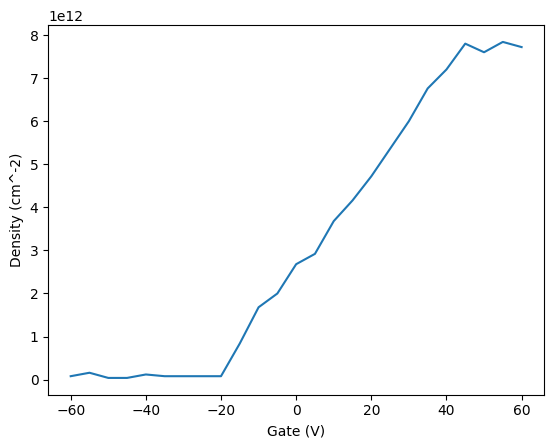

In [8]:

size=50e-7*50e-7
densities=[]
img_ds=[]
paths=[]
_kwargs={
    'diameter':5,
    'maxsize':200,
    'minmass':1,
    'separation':1}
for i in range(616,641):

    path=[f'electromigration_13/Image_{i}.sxm']
    paths.append(path)
    img_d=pc.imgdata(path,filetype='SXM',**_kwargs)
    densities.append(img_d.data.shape[0]/size)
    img_ds.append(img_d)
gates=np.linspace(60,-60,25)
plt.plot(gates,densities)
plt.xlabel('Gate (V)')
plt.ylabel('Density (cm^-2)')

In [9]:
dfs=[]
for i in range(15,40):
    df = pd.read_csv(f'electromigration_13/GBN_237_transport_{i:03d}.dat',delimiter='\t',header=7)
    dfs.append(df)

In [10]:
for i in range(15,40):
    print(f'electromigration_13/GBN_237_transport_{i:03d}.dat')

electromigration_13/GBN_237_transport_015.dat
electromigration_13/GBN_237_transport_016.dat
electromigration_13/GBN_237_transport_017.dat
electromigration_13/GBN_237_transport_018.dat
electromigration_13/GBN_237_transport_019.dat
electromigration_13/GBN_237_transport_020.dat
electromigration_13/GBN_237_transport_021.dat
electromigration_13/GBN_237_transport_022.dat
electromigration_13/GBN_237_transport_023.dat
electromigration_13/GBN_237_transport_024.dat
electromigration_13/GBN_237_transport_025.dat
electromigration_13/GBN_237_transport_026.dat
electromigration_13/GBN_237_transport_027.dat
electromigration_13/GBN_237_transport_028.dat
electromigration_13/GBN_237_transport_029.dat
electromigration_13/GBN_237_transport_030.dat
electromigration_13/GBN_237_transport_031.dat
electromigration_13/GBN_237_transport_032.dat
electromigration_13/GBN_237_transport_033.dat
electromigration_13/GBN_237_transport_034.dat
electromigration_13/GBN_237_transport_035.dat
electromigration_13/GBN_237_transp

In [36]:
gates[-1]

-60.0

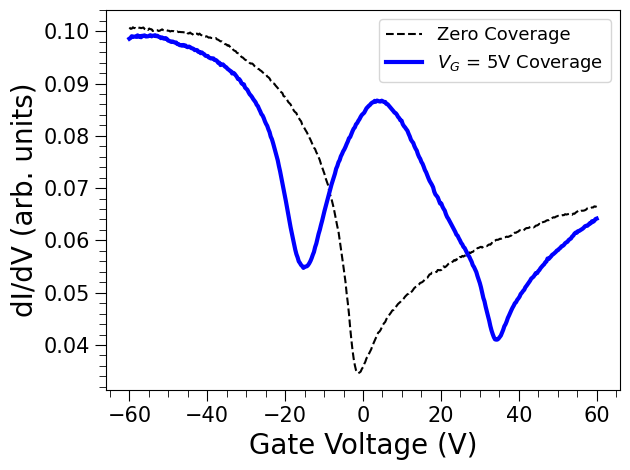

In [12]:

fig=plt.figure()
plt.plot((dfs[-1]['Gate (V)']),((dfs[-1]['LI Y (V)']))
        ,linestyle='--',label="Zero Coverage",color='black')
plt.plot((dfs[11]['Gate (V)']),((dfs[11]['LI Y (V)']))
        ,label="$V_G$ = 5V Coverage ",linewidth=3,marker=None,color='blue')
plt.xlabel('Gate Voltage (V)',fontsize=20)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', labelsize=15,length=8)
plt.tick_params(axis='both', which='minor',length=5)
plt.ylabel('dI/dV (arb. units)',fontsize=20)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig('./Luc Folder/5Vv-60V.svg')

In [22]:
gates

array([ 60.,  55.,  50.,  45.,  40.,  35.,  30.,  25.,  20.,  15.,  10.,
         5.,   0.,  -5., -10., -15., -20., -25., -30., -35., -40., -45.,
       -50., -55., -60.])

In [41]:
norm(60)

1.0

In [46]:
norm = Normalize(vmin=-60, vmax=60)  # Normalize the color bar to the range of y values


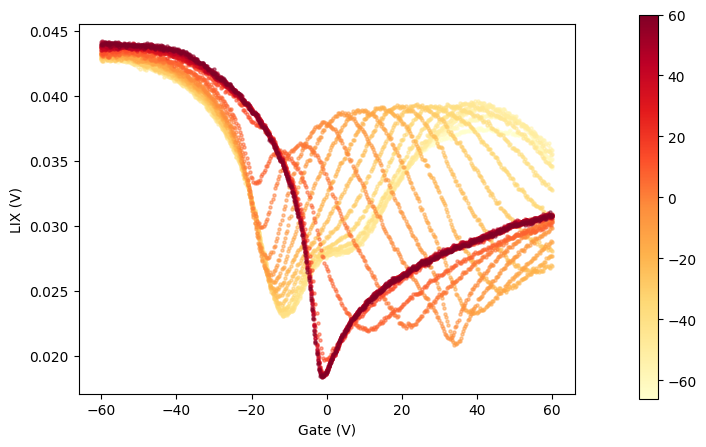

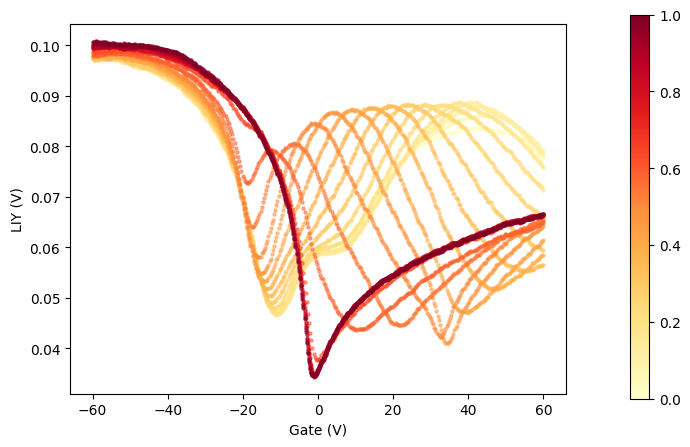

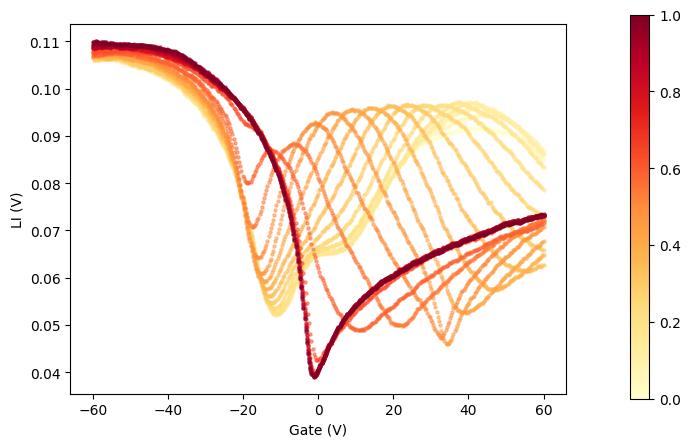

In [58]:
plt.cm.get_cmap("YlOrRd")
cmap=plt.cm.get_cmap("YlOrRd")
colors = cmap(np.linspace(0,1,25))
norm = Normalize(vmin=60, vmax=-60)  # Normalize the color bar to the range of y values
fig=plt.figure()
for i in range(25):
    plt.xlabel('Gate (V)')
    plt.ylabel('LIX (V)')
    plt.scatter(dfs[i]['Gate (V)'],dfs[i]['LI X (V)'],color=colors[i],alpha=0.5,s=5,
               label=f'{gates[i]} V')
cbar = ColorbarBase(
    ax=fig.add_axes([1, 0.1, 0.03, 0.8]),
    cmap=cmap, orientation='vertical',norm=norm)
#cbar.ax.invert_yaxis()
fig=plt.figure()
for i in range(25):
    plt.xlabel('Gate (V)')
    plt.ylabel('LIY (V)')
    plt.scatter(dfs[i]['Gate (V)'],dfs[i]['LI Y (V)'],color=colors[i],alpha=0.5,s=5,
               label=f'{gates[i]} V')
cbar = ColorbarBase(
    ax=fig.add_axes([1, 0.1, 0.03, 0.8]),
    cmap=plt.get_cmap(cmap), orientation='vertical',)
fig=plt.figure()
for i in range(25):
    plt.xlabel('Gate (V)')
    plt.ylabel('LI (V)')
    plt.scatter(dfs[i]['Gate (V)'],(dfs[i]['LI Y (V)']**2+dfs[i]['LI X (V)']**2)**0.5,color=colors[i],alpha=0.5,s=5,
               label=f'{gates[i]} V')
cbar = ColorbarBase(
    ax=fig.add_axes([1, 0.1, 0.03, 0.8]),
    cmap=plt.get_cmap(cmap), orientation='vertical',)


In [ ]:
i=13
plt.title(f'Applied Gate= {gates[i]} V')
plt.xlabel('Gate (V)')
plt.ylabel('LI (V)')
plt.scatter(dfs[i]['Gate (V)'],dfs[i]['LI X (V)'],label='LIX')
plt.scatter(dfs[i]['Gate (V)'],dfs[i]['LI Y (V)'],label='LIY')
plt.scatter(dfs[i]['Gate (V)'],
            (dfs[i]['LI Y (V)']**2+dfs[i]['LI Y (V)']**2)**0.5,label='Magnitude')

plt.legend()

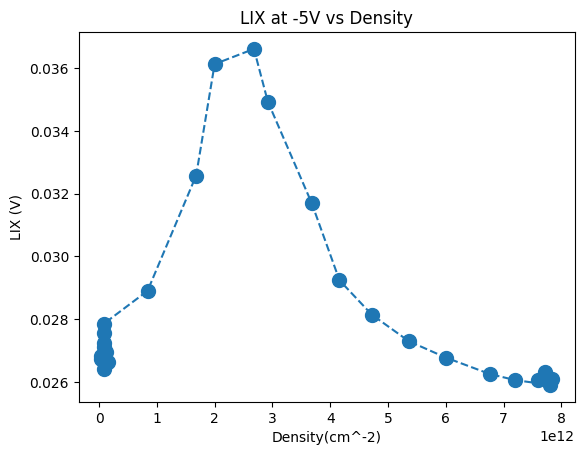

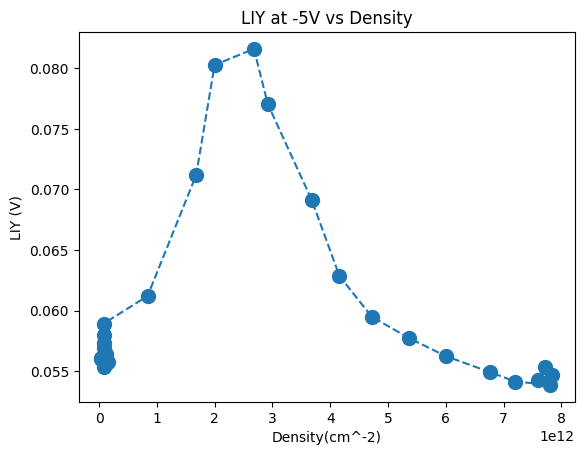

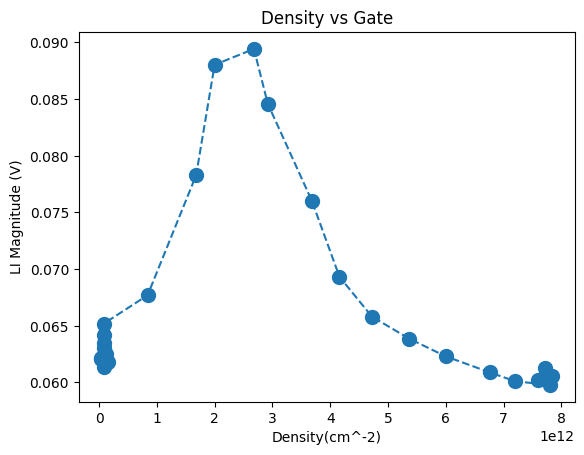

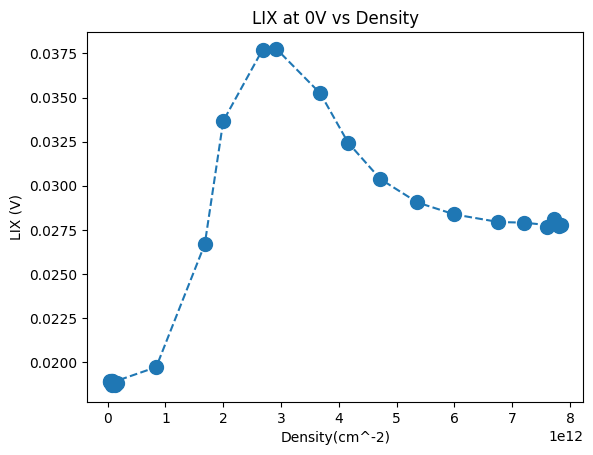

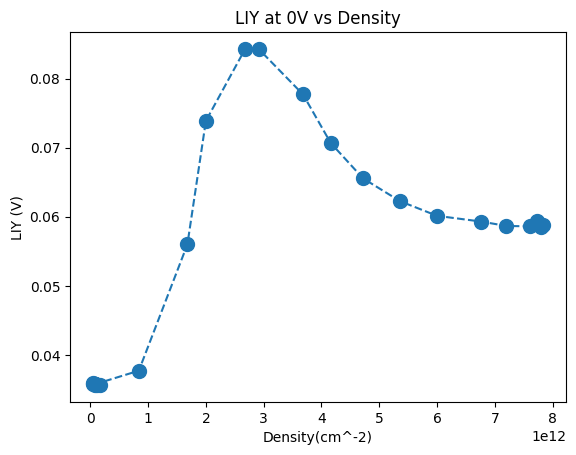

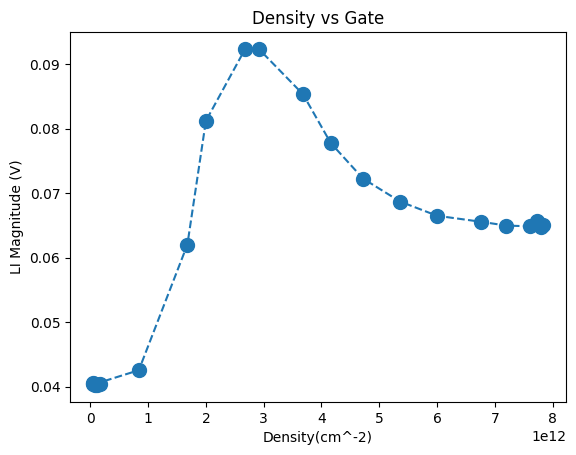

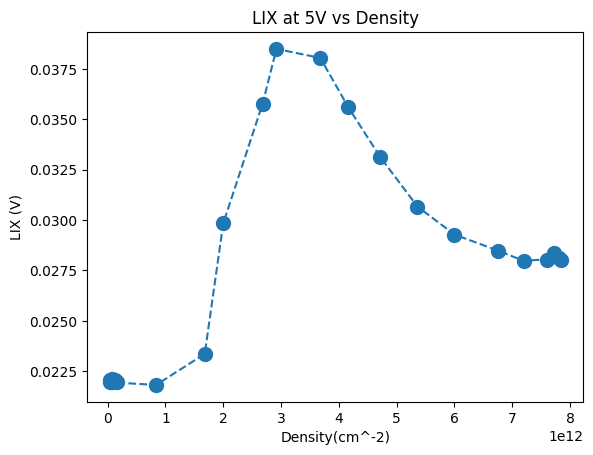

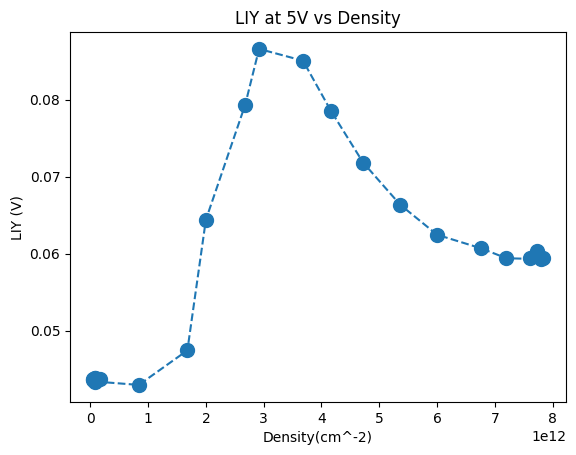

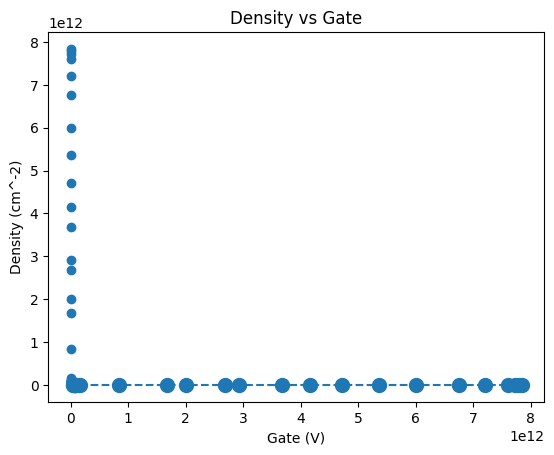

In [59]:
LIX=[]
LIY=[]
for i in range(25):
    df=dfs[i]
    LIX.append([df[df['Gate (V)']==-5.1]['LI X (V)'],
              df[df['Gate (V)']==0]['LI X (V)'],
              df[df['Gate (V)']==5.1]['LI X (V)']])
    LIY.append([df[df['Gate (V)']==-5.1]['LI Y (V)'],
              df[df['Gate (V)']==0]['LI Y (V)'],
              df[df['Gate (V)']==5.1]['LI Y (V)']])
LIX=np.array(LIX)
LIY=np.array(LIY)
names=['Gs','Density','LIX-5','LIX0','LIX5','LIY-5','LIY0','LIY5']
lists=[gates, densities,LIX[:,0,0],LIX[:,1,0],LIX[:,2,0],LIY[:,0,0],LIY[:,1,0],LIY[:,2,0]]
_data = {name: lst for name, lst in zip(names,
                                       lists)}
data=pd.DataFrame(_data)
Gms=['-5','0','5']
for i in range(3):
    plt.figure()
    plt.title('LIX at '+Gms[i]+'V vs Density')
    plt.xlabel('Density(cm^-2)')
    plt.ylabel('LIX (V)')
    plt.plot(data['Density'],data['LIX'+Gms[i]],markersize=10,marker='o',linestyle='--')
    plt.figure()
    plt.title('LIY at '+Gms[i]+'V vs Density')
    plt.xlabel('Density(cm^-2)')
    plt.ylabel('LIY (V)')
    plt.plot(data['Density'],data['LIY'+Gms[i]],markersize=10,marker='o',linestyle='--')
    plt.figure()
    plt.title('LI Magnitude at '+Gms[i]+'V vs Density')
    plt.xlabel('Density(cm^-2)')
    plt.ylabel('LI Magnitude (V)')
    plt.plot(data['Density'],(data['LIY'+Gms[i]]**2+data['LIX'+Gms[i]]**2)**0.5,markersize=10,marker='o',linestyle='--')
    plt.title("Density vs Gate")
plt.xlabel('Gate (V)')
plt.ylabel('Density (cm^-2)')
plt.scatter(data['Gs'],data['Density'])